# Geographic plotting

This notebook explores how to correctly visualize a raster in its correct position on the Earth model. When we load a raster from a GeoTIFF image, each pixel is stored in the raster position at a specific index. To properly visualzia a raster, we need to convert the pixel position into a Cartesian one.

In [5]:
from dotenv import load_dotenv

# ; to suppress the output.
load_dotenv();

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio import transform
from rasterio.transform import xy

In [7]:
# One example image from Andalusia.
href_andalusia = "s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/12/27/S2B_MSIL2A_20221227T111359_N0510_R137_T30STG_20240807T153102.SAFE/GRANULE/L2A_T30STG_A030336_20221227T111439/IMG_DATA/R10m/T30STG_20221227T111359_B02_10m.jp2"

In [8]:
with rasterio.open(href_andalusia) as src:
    data = src.read(1)
    transform = src.transform
    bounds = src.bounds

In [11]:
def get_raster_extent(raster, transform) -> list:
    """Return the extent information of the raster on a Cartesian Earth system."""
    return [
        transform.c,
        transform.c + transform.a * raster.shape[1],
        transform.f + transform.e * raster.shape[0],  # the y pixel size is negative
        transform.f,
    ]

In [12]:
get_raster_extent(data, transform)

[199980.0, 309780.0, 4090200.0, 4200000.0]

We can verify the computation using the affine transformation by looking at the bound values from the GeoTIFF image:

In [13]:
bounds

BoundingBox(left=199980.0, bottom=4090200.0, right=309780.0, top=4200000.0)

When we visualize an image, we want to take advantage of the entire color scale. If we have outliers in the data, they will compress the color range available for the correct pixels. We can correct this behavior by setting the min and max in the colormap at some percentile values. In this way, we can obtain a more robust visualization of the raster:

In [14]:
vmin, vmax = np.percentile(data, [2, 98])

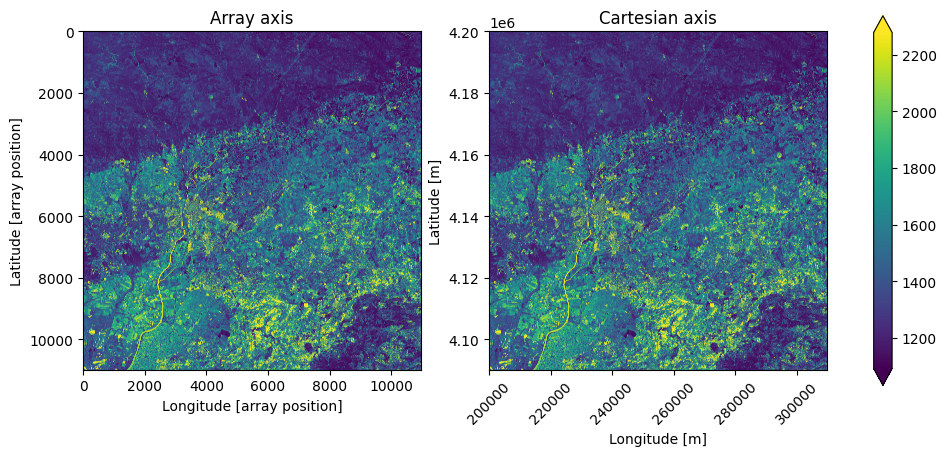

In [18]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 8))

im = ax[0].imshow(data, cmap="viridis", vmin=vmin, vmax=vmax)
ax[0].set_title(f"Array axis", size="large")
ax[0].set_xlabel("Longitude [array position]")
ax[0].set_ylabel("Latitude [array position]")

extent = get_raster_extent(data, transform)
ax[1].imshow(
    data,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=extent,
)
ax[1].tick_params(axis="x", rotation=45)
ax[1].set_title(f"Cartesian axis", size="large")
ax[1].set_xlabel("Longitude [m]")
ax[1].set_ylabel("Latitude [m]")
plt.colorbar(im, ax=ax, shrink=0.6, extend="both")

plt.show()